я надумав опрацювати краще дані по вінрейту кожної з команд - знайти standart deviation між перемогами вдома і гостях, 1. outliers - команди які краще грають вдома краще, ніж інші. тобто в який відсоток переміг замітно більший за sd. 2. також список команд, які грають краще на виїзді 3. відсортувати по сезонам і по лігам цю інформацію

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import helpers as hp
import matplotlib.pyplot as plt

In [2]:
team_stats = pd.read_csv("team_stats.csv")

In [3]:
team_stats.head()

,Club,League,Season,D,L,W,GF_home,GA_home,GF_away,GA_away,...,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
0,1. FC Kaiserslautern,Germany 1. Bundesliga,2010/2011,7,14,13,25,19,23,32,...,51,6,5,6,1,9,7,0.352941,0.411765,-0.058824
1,1. FC Kaiserslautern,Germany 1. Bundesliga,2011/2012,11,19,4,12,28,12,26,...,54,5,10,2,6,9,2,0.117647,0.117647,0.000000
2,1. FC Köln,Germany 1. Bundesliga,2008/2009,6,17,11,14,25,21,25,...,50,5,8,4,1,9,7,0.235294,0.411765,-0.176471
3,1. FC Köln,Germany 1. Bundesliga,2009/2010,11,14,9,18,29,15,13,...,42,6,8,3,5,6,6,0.176471,0.352941,-0.176471
4,1. FC Köln,Germany 1. Bundesliga,2010/2011,5,16,13,30,21,17,41,...,62,2,4,11,3,12,2,0.647059,0.117647,0.529412


In [4]:
team_stats["home_advantage"].count()

np.int64(1478)

In [5]:
team_stats["home_advantage"].value_counts()

home_advantage
 0.000000    101
 0.157895     95
 0.210526     91
 0.052632     86
 0.105263     81
            ... 
-0.050000      1
 0.214286      1
 0.277778      1
 0.100000      1
 0.647059      1
Name: count, Length: 107, dtype: int64

In [6]:
team_stats["home_advantage"].nunique()

107

In [7]:
team_stats["home_advantage"].value_counts()

home_advantage
 0.000000    101
 0.157895     95
 0.210526     91
 0.052632     86
 0.105263     81
            ... 
-0.050000      1
 0.214286      1
 0.277778      1
 0.100000      1
 0.647059      1
Name: count, Length: 107, dtype: int64

In [8]:
team_stats["home_advantage"].describe()

count    1478.000000
mean        0.171070
std         0.157623
min        -0.666667
25%         0.058824
50%         0.166667
75%         0.266667
max         0.736842
Name: home_advantage, dtype: float64

Distribution of home advantage for every team and every season 

Text(0, 0.5, 'Frequency')

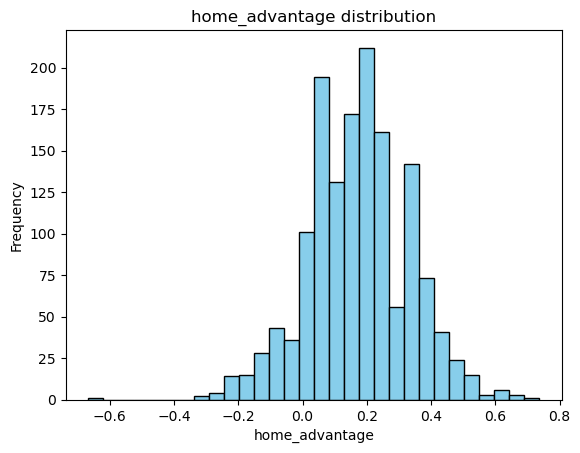

In [9]:
plt.hist(team_stats["home_advantage"], bins=30, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

But this data is a bit unfair. There are teams that play 1 season and they are too bad for the league. There's also teams, who "have one hit wonder" seasons. We should eliminate teams, who played less then 4 seasons from our analysis, so we'll have to deal only with teams that have enough data to make some assumptions. First of all we'll have to create new df for teams with 4+ seasons of data.

In [10]:
team_stats["Club"].value_counts()

Club
Śląsk Wrocław       8
FC Sion             8
Getafe CF           8
Genoa               8
Stade Rennais FC    8
                   ..
Reading             1
FC Metz             1
FC Ingolstadt 04    1
Trofense            1
Le Havre AC         1
Name: count, Length: 296, dtype: int64

In [11]:
four_seasons = (team_stats['Club'].value_counts()>=4)

In [12]:
four_seasons.head()

Club
Śląsk Wrocław       True
FC Sion             True
Getafe CF           True
Genoa               True
Stade Rennais FC    True
Name: count, dtype: bool

In [13]:
four_seasons.count()

np.int64(296)

In [14]:
four_seasons = four_seasons[four_seasons == True]

In [15]:
four_seasons.count()

np.int64(194)

In [16]:
four_seasons.index

Index(['Śląsk Wrocław', 'FC Sion', 'Getafe CF', 'Genoa', 'Stade Rennais FC',
       'Polonia Bytom', 'Fiorentina', 'Feyenoord', 'Stoke City', 'Sunderland',
       ...
       'Stade de Reims', 'Waasland-Beveren', 'Bolton Wanderers', 'Hull City',
       'Siena', 'Sint-Truidense VV', 'Évian Thonon Gaillard FC', 'AJ Auxerre',
       'Estoril Praia', 'Southampton'],
      dtype='object', name='Club', length=194)

In [17]:
team_stats_filtered = team_stats[team_stats["Club"].isin(four_seasons.index)]

In [18]:
team_stats_filtered.count()

Club              1298
League            1298
Season            1298
D                 1298
L                 1298
W                 1298
GF_home           1298
GA_home           1298
GF_away           1298
GA_away           1298
GF                1298
GA                1298
D_home            1298
L_home            1298
W_home            1298
D_away            1298
L_away            1298
W_away            1298
home_winrate      1298
away_winrate      1298
home_advantage    1298
dtype: int64

In [19]:
team_stats_filtered["home_advantage"].describe()

count    1298.000000
mean        0.177434
std         0.157342
min        -0.333333
25%         0.058824
50%         0.176471
75%         0.294118
max         0.736842
Name: home_advantage, dtype: float64

Removed clubs with fewer seasons, still built histogram to see if there's some noticable changes. As we can see - none

Text(0, 0.5, 'Frequency')

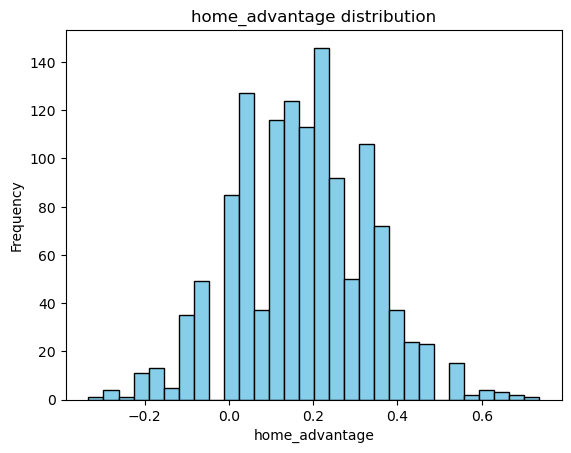

In [20]:
plt.hist(team_stats_filtered["home_advantage"], bins=30, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

Now we'll just have to groupby teams by seasons, so we'll see home_advantage grouped for all the seasons 

In [21]:
club_home_advantage = team_stats_filtered[["Club","home_advantage"]]

In [22]:
club_home_advantage.head()

,Club,home_advantage
2,1. FC Köln,-0.176471
3,1. FC Köln,-0.176471
4,1. FC Köln,0.529412
5,1. FC Köln,0.117647
6,1. FC Köln,-0.058824


In [23]:
club_home_advantage = club_home_advantage.groupby("Club")["home_advantage"].mean()

In [24]:
club_home_advantage = club_home_advantage.to_frame().reset_index()

In [25]:
print(club_home_advantage["home_advantage"].nlargest(15))

30     0.415205
99     0.335526
145    0.328947
127    0.326316
81     0.325000
117    0.323308
180    0.315789
177    0.289474
63     0.289474
146    0.289216
86     0.288675
154    0.282895
65     0.278874
55     0.271930
135    0.263158
Name: home_advantage, dtype: float64


In [26]:
club_home_advantage["home_advantage"].describe()

count    194.000000
mean       0.174681
std        0.073168
min       -0.053333
25%        0.128676
50%        0.176471
75%        0.227347
max        0.415205
Name: home_advantage, dtype: float64

In [27]:
club_home_advantage.groupby("Club")["home_advantage"].mean().nsmallest(15)

Club
Podbeskidzie Bielsko-Biała     -0.053333
Hamilton Academical FC         -0.042105
Inverness Caledonian Thistle    0.000000
Hibernian                       0.008772
Aston Villa                     0.026316
FC Zürich                       0.026552
Chievo Verona                   0.032895
1. FC Köln                      0.039216
Racing Santander                0.039474
AS Nancy-Lorraine               0.042105
Rangers                         0.052632
St. Mirren                      0.052632
St. Johnstone FC                0.059315
Real Betis Balompié             0.063158
Wigan Athletic                  0.063158
Name: home_advantage, dtype: float64

In [28]:
club_home_advantage.groupby("Club")["home_advantage"].mean().nlargest(15)

Club
Catania                   0.415205
Manchester City           0.335526
SC Bastia                 0.328947
RCD Mallorca              0.326316
Jagiellonia Białystok     0.325000
Palermo                   0.323308
Villarreal CF             0.315789
Valenciennes FC           0.289474
Fulham                    0.289474
SC Braga                  0.289216
KV Kortrijk               0.288675
Sevilla FC                0.282895
Genoa                     0.278874
FC Sochaux-Montbéliard    0.271930
Real Sociedad             0.263158
Name: home_advantage, dtype: float64

Text(0, 0.5, 'Frequency')

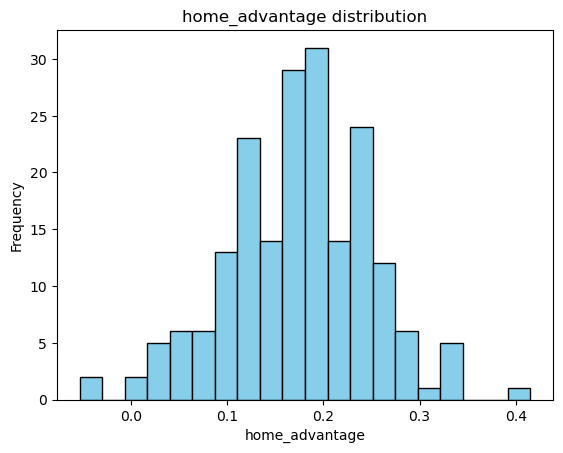

In [29]:
plt.hist(club_home_advantage["home_advantage"], bins=20, edgecolor='black', color='skyblue')
plt.title('home_advantage distribution')
plt.xlabel('home_advantage')
plt.ylabel('Frequency')

As we can see -  most clubs gather around 10 to 25 % better results at home with an average of ~17%. We've managed to remove clear outliers from our study. Standart deviation was 0.157, and now only 0.07 - that is more then a significant change. Extreme values in our first try was teams:
1. who perform bad and got relegated to lower division
2. who had significant season
3. by coincidence(meaning it just happens sometimes that you lose some games at home and away you perform better)

Through first filtration we've removed weak teams who out of 8 seasons managed to spend in top flight only 3 or less years. But this operation have made no impact, cause there was still teams with exceptionally good and bad seasons. So we'll have to find the mean for all teams all seasons.

Through second filtration we've removed any significant season chances by grouping home advantage and finding the mean out of this values. That made us a lot more confident in the data. We have almost no extreme values. The couple we still have will be object of further investigation.

The distribution appears approximately bell-shaped.

# Home advantage per league
I'm also interested to check if there are leagues where distribution changes. We'll check couple of them.

In [30]:
team_stats_filtered.head()

,Club,League,Season,D,L,W,GF_home,GA_home,GF_away,GA_away,...,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
2,1. FC Köln,Germany 1. Bundesliga,2008/2009,6,17,11,14,25,21,25,...,50,5,8,4,1,9,7,0.235294,0.411765,-0.176471
3,1. FC Köln,Germany 1. Bundesliga,2009/2010,11,14,9,18,29,15,13,...,42,6,8,3,5,6,6,0.176471,0.352941,-0.176471
4,1. FC Köln,Germany 1. Bundesliga,2010/2011,5,16,13,30,21,17,41,...,62,2,4,11,3,12,2,0.647059,0.117647,0.529412
5,1. FC Köln,Germany 1. Bundesliga,2011/2012,6,20,8,20,29,19,46,...,75,4,8,5,2,12,3,0.294118,0.176471,0.117647
6,1. FC Köln,Germany 1. Bundesliga,2014/2015,13,12,9,18,17,16,23,...,40,9,4,4,4,8,5,0.235294,0.294118,-0.058824


In [31]:
league_home_advantage = team_stats_filtered[["Club","League","home_advantage"]]

In [32]:
league_home_advantage.head()

,Club,League,home_advantage
2,1. FC Köln,Germany 1. Bundesliga,-0.176471
3,1. FC Köln,Germany 1. Bundesliga,-0.176471
4,1. FC Köln,Germany 1. Bundesliga,0.529412
5,1. FC Köln,Germany 1. Bundesliga,0.117647
6,1. FC Köln,Germany 1. Bundesliga,-0.058824


In [33]:
league_home_advantage = league_home_advantage.groupby(["Club","League"])["home_advantage"].mean().reset_index()

In [34]:
type(league_home_advantage)

pandas.core.frame.DataFrame

In [35]:
league_home_advantage.head()

,Club,League,home_advantage
0,1. FC Köln,Germany 1. Bundesliga,0.039216
1,1. FC Nürnberg,Germany 1. Bundesliga,0.129412
2,1. FSV Mainz 05,Germany 1. Bundesliga,0.184874
3,ADO Den Haag,Netherlands Eredivisie,0.154412
4,AJ Auxerre,France Ligue 1,0.118421


In [36]:
league_home_advantage["home_advantage"].info()

<class 'pandas.core.series.Series'>
RangeIndex: 194 entries, 0 to 193
Series name: home_advantage
Non-Null Count  Dtype  
--------------  -----  
194 non-null    float64
dtypes: float64(1)
memory usage: 1.6 KB


In [37]:
league_home_advantage.groupby("League")["home_advantage"].mean().sort_values()

League
Scotland Premier League     0.082217
Portugal Liga ZON Sagres    0.150641
Germany 1. Bundesliga       0.155910
Switzerland Super League    0.161193
Poland Ekstraklasa          0.168912
England Premier League      0.177703
France Ligue 1              0.183011
Belgium Jupiler League      0.188739
Netherlands Eredivisie      0.190756
Spain LIGA BBVA             0.201590
Italy Serie A               0.211673
Name: home_advantage, dtype: float64

In [38]:
league_home_advantage["home_advantage"].describe()

count    194.000000
mean       0.174681
std        0.073168
min       -0.053333
25%        0.128676
50%        0.176471
75%        0.227347
max        0.415205
Name: home_advantage, dtype: float64

In [39]:
league_home_advantage.groupby("League")["home_advantage"].describe()

,count,mean,std,min,25%,50%,75%,max
League,,,,,,,,
Belgium Jupiler League,16.0,0.188739,0.062808,0.077111,0.153046,0.200730,0.239976,0.288675
England Premier League,21.0,0.177703,0.072036,0.026316,0.142857,0.164474,0.210526,0.335526
France Ligue 1,21.0,0.183011,0.072254,0.042105,0.126316,0.190789,0.236842,0.328947
Germany 1. Bundesliga,18.0,0.155910,0.056563,0.039216,0.125000,0.138480,0.184611,0.242647
Italy Serie A,19.0,0.211673,0.080390,0.032895,0.178954,0.210526,0.240758,0.415205
Netherlands Eredivisie,20.0,0.190756,0.041990,0.110294,0.166492,0.183824,0.235294,0.257353
Poland Ekstraklasa,17.0,0.168912,0.079687,-0.053333,0.133333,0.166667,0.208333,0.325000
Portugal Liga ZON Sagres,15.0,0.150641,0.056341,0.080000,0.112255,0.150980,0.183088,0.289216
Scotland Premier League,13.0,0.082217,0.075702,-0.042105,0.052632,0.065899,0.111842,0.233083


As we can see after we've described home_advantage for each league, there are some leagues with  not enough data to form reasonable conclussion. For example Swiss league has only 10 teams to make conclussions on. But nevertheless - their mean and std not too far off from average for clubs in all leagues. 

Another observation - number of teams with 4+ seasons spent in top flight is similair to the number of allowed teams in 1 season 1 league. ie germany really has 18 teams in top flight, england is really close with 21, italy with 19 - the same. Only Spain and France has a bit more then usual, but there can be a lot of reasons for this. Maybe we'll later investigate it.

We can also see that there's unusually low mean for Scotland Premier League. It means(no put intended) that there's a lot less difference at where do team play on average for teams playing this league. Compared to overall mean it is two times lower. Maybe there are dominant teams(Celtic and Rangers) that do not care where to play against much weaker opponents. I remember that both those teams were really good both at home and away winrate in my simple_data_analysis.ipynb notebook. We'll have to check all the teams in this league to understand what's going on

In [40]:
league_home_advantage.groupby("League")["home_advantage"].std()

League
Belgium Jupiler League      0.062808
England Premier League      0.072036
France Ligue 1              0.072254
Germany 1. Bundesliga       0.056563
Italy Serie A               0.080390
Netherlands Eredivisie      0.041990
Poland Ekstraklasa          0.079687
Portugal Liga ZON Sagres    0.056341
Scotland Premier League     0.075702
Spain LIGA BBVA             0.074850
Switzerland Super League    0.063320
Name: home_advantage, dtype: float64

<Axes: title={'center': 'home_advantage'}, ylabel='[League]'>

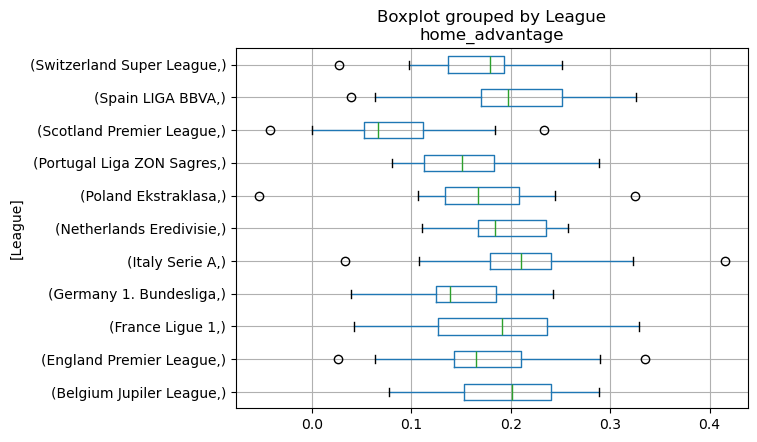

In [41]:
league_home_advantage.boxplot(column = ["home_advantage"], by = ["League"], vert = False,layout=(1,1))

Based on home advantage boxplot for leagues we can come to several conclusions:
1. Poland, Netherlands and Switzerland appear to have more compact distribution. This may be related to the relatively small number of clubs included in the analysis, although this would require further investigation.
2. Several leagues, particularly Scotland, Poland and Italy, contain clubs that are identified as potential outliers according to the boxplot. These clubs differ substantially from the rest of the clubs within their respective leagues.
3. There is more variability in home advatage between clubs in Spain and France, to lesser extent in Italy and England.  

In [42]:
league_home_advantage

,Club,League,home_advantage
0,1. FC Köln,Germany 1. Bundesliga,0.039216
1,1. FC Nürnberg,Germany 1. Bundesliga,0.129412
2,1. FSV Mainz 05,Germany 1. Bundesliga,0.184874
3,ADO Den Haag,Netherlands Eredivisie,0.154412
4,AJ Auxerre,France Ligue 1,0.118421
...,...,...,...
189,Willem II,Netherlands Eredivisie,0.176471
190,Wisła Kraków,Poland Ekstraklasa,0.166667
191,Zagłębie Lubin,Poland Ekstraklasa,0.122222
192,Évian Thonon Gaillard FC,France Ligue 1,0.171053


# Now we'll dive deeper into outliers and what makes them outliers

In [54]:
italian_league_stats = league_home_advantage[league_home_advantage["League"] == "Italy Serie A"]

In [55]:
italian_league_stats  = team_stats_filtered[team_stats_filtered["League"] == "Italy Serie A"]

In [56]:
italian_league_stats

,Club,League,Season,D,L,W,GF_home,GA_home,GF_away,GA_away,...,GA,D_home,L_home,W_home,D_away,L_away,W_away,home_winrate,away_winrate,home_advantage
111,Atalanta,Italy Serie A,2008/2009,8,17,13,28,17,17,31,...,48,3,6,10,5,11,3,0.526316,0.157895,0.368421
112,Atalanta,Italy Serie A,2009/2010,8,21,9,24,20,13,33,...,53,5,7,7,3,14,2,0.368421,0.105263,0.263158
113,Atalanta,Italy Serie A,2011/2012,11,11,13,22,14,18,26,...,40,5,4,9,6,7,4,0.500000,0.222222,0.277778
114,Atalanta,Italy Serie A,2012/2013,9,18,11,19,24,20,32,...,56,6,7,6,3,11,5,0.315789,0.263158,0.052632
115,Atalanta,Italy Serie A,2013/2014,5,18,15,28,22,15,29,...,51,3,5,11,2,13,4,0.578947,0.210526,0.368421
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1335,Udinese,Italy Serie A,2011/2012,9,9,18,33,13,19,21,...,34,3,2,13,6,7,5,0.722222,0.277778,0.444444
1336,Udinese,Italy Serie A,2012/2013,12,8,18,31,16,28,29,...,45,7,1,11,5,7,7,0.578947,0.368421,0.210526
1337,Udinese,Italy Serie A,2013/2014,8,18,12,27,24,19,33,...,57,4,6,9,4,12,3,0.473684,0.157895,0.315789
1338,Udinese,Italy Serie A,2014/2015,11,17,10,26,29,17,27,...,56,5,8,6,6,9,4,0.315789,0.210526,0.105263


In [52]:
italian_league_stats = team_stats_filtered.groupby("Club")